# Progetto del corso - Introduzione al Pensiero Computazionale e alla Data Science

**Dataset scelto:** Employee Attrition
**Obiettivo:** previsione dell'abbandono dei dipendenti (`Attrition`)

**Team:** [Paolo Magnanelli - 1231652], [Asia Milan -  0001217247].

---
# Fase 1 - Setup del progetto

In questa cella importiamo le librerie che useremo in tutto il notebook.

- `pandas`, `numpy` per la gestione dei dati
- `matplotlib`, `seaborn` per le visualizzazioni
- `scikit-learn` per modellazione e metriche

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

In [3]:
df = pd.read_csv("Employee_Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---
# Fase 2 - Descrizione e comprensione del dataset

Lo schema che useremo per ogni domanda è:

1. esposizione della domanda/ipotesi;
2. recupero e visualizzazione dell'informazione;
3. risposta/considerazione.

**Iniziamo con una panoramica**: dimensioni, tipi di variabili e presenza di
valori mancanti.

In [4]:
print("Numero di righe:", df.shape[0])
print("Numero di colonne:", df.shape[1])
df.info()

Numero di righe: 1470
Numero di colonne: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Considerazioni:** il dataset contiene 1470 osservazioni (dipendenti) e 35
colonne. Non sono presenti tipi di dato anomali a prima vista: la maggior parte
delle variabili è numerica (int64), mentre alcune sono categoriche (stringhe).
Procediamo a verificare i valori mancanti.

### Domanda 1 - Ci sono valori mancanti?

In [6]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


**Considerazioni:** non risultano valori mancanti (`NaN`) in nessuna colonna.


### Domanda 2 - Quali sono le variabili numeriche e quali categoriche?


In [7]:
print("Variabili nuemriche e catgoriche:")
df.dtypes.value_counts()

Variabili nuemriche e catgoriche:


,count
int64,26
object,9


In [8]:
numeriche = df.select_dtypes(include="number").columns
categoriche = df.select_dtypes(exclude="number").columns

print("Variabili numeriche:")
for col in numeriche:
    print("-", col)

print("\nVariabili categoriche:")
for col in categoriche:
    print("-", col)

Variabili numeriche:
- Age
- DailyRate
- DistanceFromHome
- Education
- EmployeeCount
- EmployeeNumber
- EnvironmentSatisfaction
- HourlyRate
- JobInvolvement
- JobLevel
- JobSatisfaction
- MonthlyIncome
- MonthlyRate
- NumCompaniesWorked
- PercentSalaryHike
- PerformanceRating
- RelationshipSatisfaction
- StandardHours
- StockOptionLevel
- TotalWorkingYears
- TrainingTimesLastYear
- WorkLifeBalance
- YearsAtCompany
- YearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManager

Variabili categoriche:
- Attrition
- BusinessTravel
- Department
- EducationField
- Gender
- JobRole
- MaritalStatus
- Over18
- OverTime


**Considerazioni:** ci sono 26 variabili numeriche e 9 categoriche
(incluso il target `Attrition`). Tra le variabili categoriche troviamo
informazioni come `Department`, `JobRole`, `MaritalStatus`, `OverTime`, ecc.

### Domanda 3 - Esistono colonne che, anche se numeriche, contengono un solo valore?

Una colonna che ha sempre lo stesso valore non porta nessuna informazione utile
per un modello predittivo: è quindi importante identificarla.

In [9]:
nunique = df.nunique().sort_values()
nunique.head(10)

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [10]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Variabili costanti:", constant_cols)

Variabili costanti: ['EmployeeCount', 'Over18', 'StandardHours']


**Considerzioni**: Emerge che alcune variabili presentano un solo valore (come `EmployeeCount`, `Over18` e `StandardHours`) e quindi non forniscono informazioni utili per l’analisi.

Altre variabili hanno solo poche categorie (ad esempio `Attrition`, `OverTime`, `Gender`), sono quindi facilmente interpretabili ma con una variabilità bassa.

Infine, alcune variabili categoriali presentano più livelli (come `BusinessTravel`, `Department` e `MaritalStatus`), mostrano diversità e potenziale informativo.


### Domanda 4 -  Qual è la distribuzione della variabile target `Attrition`? Il dataset è bilanciato o sbilanciato?


In [11]:
attrition_counts = df["Attrition"].value_counts()
attrition_per = df["Attrition"].value_counts(normalize=True) * 100

print(attrition_counts)
print()
print(attrition_per.round(2)) #solo due decimali

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


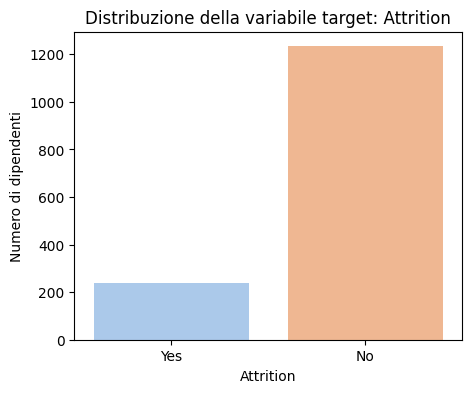

In [12]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df,
              x="Attrition",
              hue="Attrition",
              palette="pastel",
)
plt.xlabel("Attrition")
plt.ylabel("Numero di dipendenti")

plt.title("Distribuzione della variabile target: Attrition")
plt.show()

**Considerazioni:** la classe `Yes` (dipendenti che hanno lasciato
l'azienda) rappresenta circa il 16% del dataset, contro l'84% della classe
`No`. Si tratta quindi di un dataset **sbilanciato (class imbalance)**: questo
sarà importante in fase 4/5, perché un modello che predice sempre `No`
otterrebbe un'accuracy "ingannevole" di circa l'84% senza essere effettivamente
utile.

### Domanda 5 - Quali sono le statistiche descrittive principali delle variabili numeriche più rilevanti?


In [13]:
df[["Age", "MonthlyIncome", "DistanceFromHome", "TotalWorkingYears",
    "YearsAtCompany", "JobSatisfaction"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0


**Considerazioni:** l'età media dei dipendenti è di circa 37 anni (min 18,
max 60). Il reddito mensile (`MonthlyIncome`) è molto variabile (da circa 1000 a
quasi 20000), con una deviazione standard ampia che evidenzia la presenza di
ruoli/livelli molto diversi tra loro.

`YearsAtCompany` ha una mediana inferiore
alla media. Questo indica una distribuzione asimmetrica e con outliers che influenzano la media, ovvero alcuni dipendenti di
lunga data.

### Domanda 6 - Sono presenti outlier evidenti nelle variabili numeriche rilevanti?


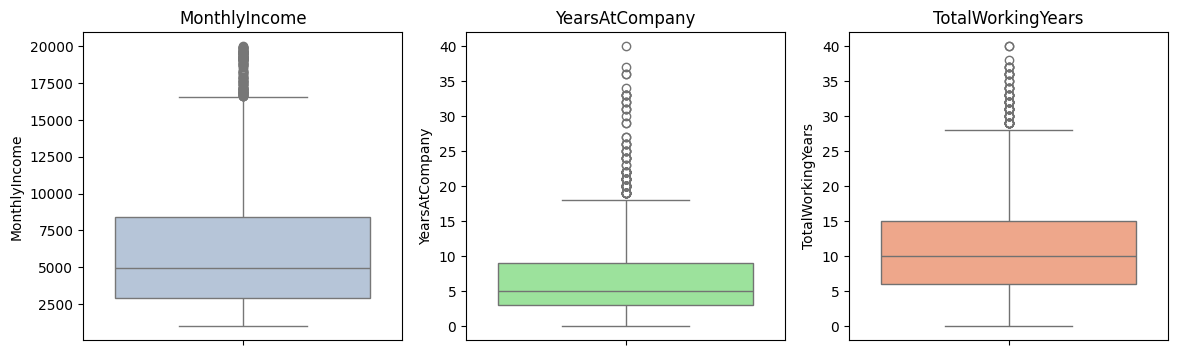

In [14]:
# crea una figura con 1 riga e 3 grafici (colonne)
# figsize controlla la dimensione del grafico (larghezza 14, altezza 4)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=df, y="MonthlyIncome", ax=axes[0], color="lightsteelblue")
# ax=axes[0] -> primo spazio del grafico (a sinistra)
axes[0].set_title("MonthlyIncome")

sns.boxplot(data=df, y="YearsAtCompany", ax=axes[1], color="lightgreen")
axes[1].set_title("YearsAtCompany")

sns.boxplot(data=df, y="TotalWorkingYears", ax=axes[2], color="lightsalmon")
axes[2].set_title("TotalWorkingYears")

plt.show()

**Considerazioni**: usiamo dei boxplot per individuare visivamente valori estremi.

Tutte e tre le variabili mostrano alcuni outliers. Tuttavia questi valori (es. dipendenti con molti anni di servizio o stipendi alti) rappresentano situazioni realistiche e non errori di inserimento dati. Si tratta probabilmente di dipendenti senior/dirigenziali. **Ne teniamo conto nell'interpretazione dei risultati**.

### Domanda 7 - Quali sono le categorie più frequenti nelle variabili categoriche principali?


In [15]:
for col in ["Department", "JobRole", "MaritalStatus", "BusinessTravel", "OverTime"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).round(4) * 100)
    print()

--- Department ---
Department
Research & Development    65.37
Sales                     30.34
Human Resources            4.29
Name: proportion, dtype: float64

--- JobRole ---
JobRole
Sales Executive              22.18
Research Scientist           19.86
Laboratory Technician        17.62
Manufacturing Director        9.86
Healthcare Representative     8.91
Manager                       6.94
Sales Representative          5.65
Research Director             5.44
Human Resources               3.54
Name: proportion, dtype: float64

--- MaritalStatus ---
MaritalStatus
Married     45.78
Single      31.97
Divorced    22.24
Name: proportion, dtype: float64

--- BusinessTravel ---
BusinessTravel
Travel_Rarely        70.95
Travel_Frequently    18.84
Non-Travel           10.20
Name: proportion, dtype: float64

--- OverTime ---
OverTime
No     71.7
Yes    28.3
Name: proportion, dtype: float64



**Considerazioni**: la maggior parte dei dipendenti:
* lavora nel dipartimento "Research & Development" (circa 65%),
* è sposata (circa 46%),
* viaggia raramente per lavoro ("Travel_Rarely", circa 71%).

Circa il 28% dei dipendenti fa straordinari (`OverTime` = Yes). **Questa variabile sarà particolarmente interessante da analizzare in fase 3, perché spesso è associata all'`attrition`**.

# Domande 8 - Alcune features numeriche sono fortemente correlate tra loro?

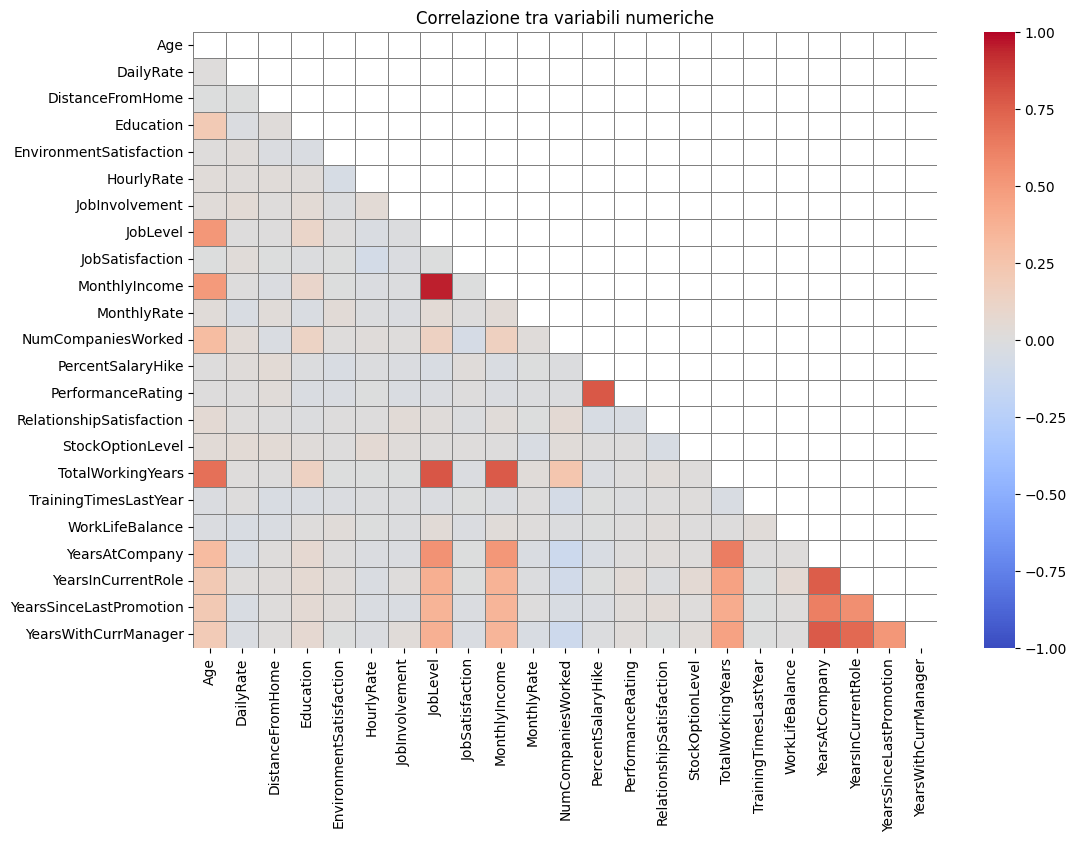

In [16]:
variabili = [col for col in df.select_dtypes(include="number")
             if col not in constant_cols + ["EmployeeNumber"]]

corr = df[variabili].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask= mask,
    cmap= "coolwarm",
    vmin= -1,
    vmax= 1,
    center= 0,
    linewidths= 0.7,        #linee più spesse
    linecolor= "gray"      #colore delle linee
)

plt.title("Correlazione tra variabili numeriche")
plt.show()


In [17]:
lista= []


for col1 in corr.columns:
    for col2 in corr.columns:
        if col1 < col2:
            valore= corr.loc[col1, col2]
            lista.append([col1, col2, abs(valore)])


tabella= pd.DataFrame(lista, columns=["Variabile 1", "Variabile 2", "Correlazione"])
tabella= tabella.sort_values(by="Correlazione", ascending=False)

top10= tabella.head(10)
print(top10)

            Variabile 1              Variabile 2  Correlazione
134            JobLevel            MonthlyIncome      0.950300
141            JobLevel        TotalWorkingYears      0.782208
198   PercentSalaryHike        PerformanceRating      0.773550
168       MonthlyIncome        TotalWorkingYears      0.772893
249      YearsAtCompany     YearsWithCurrManager      0.769212
247      YearsAtCompany       YearsInCurrentRole      0.758754
251  YearsInCurrentRole     YearsWithCurrManager      0.714365
15                  Age        TotalWorkingYears      0.680381
234   TotalWorkingYears           YearsAtCompany      0.628133
248      YearsAtCompany  YearsSinceLastPromotion      0.618409


**Considerazioni**: alcune variabili numeriche sono fortemente correlate tra loro, in particolare c'è una correlazione molto elevata tra `MonthlyIncome` e `JobLevel` (circa 0.95), mostrando, come si poteva immagianre, che stipendi più alti sono correlati a lavori più elevati.

Anche `TotalWorkingYears` è fortemente correlata con `JobLevel` e `MonthlyIncome` (circa 0.78), eveidenziando che l'esperienza lavorativa totale influisce sia sul ruolo che sul reddito.

Le variabili legate alla permanenza (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`) mostrano anch’esse correlazioni elevate tra loro (tra 0.71 e 0.77), indicando una forte relazione tra anzianità e stabilità lavorativa.

Un'ulteriore correlazione significativa è tra `PercentSalaryHike` e `PerformanceRating` (circa 0.77), quindi le performance lavorative influenzano gli aumenti salariali.

Infine, `Age` è moderatamente correlata con `TotalWorkingYears`(circa 0.68), coerentemente collegato al fatto che i lavoratori più anziani tendono ad avere una maggiore esperienza.


### Conclusioni della fase 2
1. Il dataset contiene 1470 osservazioni e 35 variabili:
  - 26 numeriche
  - 9 categoriche  

2. Non sono presenti valori mancanti, quindi i dati risultano completi.

3. La variabile target `Attrition` è sbilanciata come ci aspettavamo da un dataset HR che tratta di tale tema:
  - circa 84% dipendenti che restano  
  - circa 16% che lasciano  

4. Sono presenti alcune variabili non informative (costanti), come:
  - `EmployeeCount`
  - `Over18`
  - `StandardHours`

5. Le variabili numeriche mostrano:
  - elevata variabilità → `MonthlyIncome`
  - presenza di outlier, ma realistici → dipendenti senior

6. Le variabili categoriche evidenziano che:
  - la maggior parte lavora in "Research & Development"
  - molti sono sposati
  - circa il 28% fa straordinari  

7. L’analisi delle correlazioni mostra:
  - forte relazione tra reddito e livello del ruolo
  - legame tra esperienza, reddito e posizione lavorativa
  - alta correlazione tra variabili legate agli anni in azienda  



---
# Fase 3 - Analisi esplorativa e visualizzazione

**Obiettivo:** capire (e comunicare) le relazioni tra le feature, in particolare
rispetto al target `Attrition`.

Per facilitare i confronti, creiamo una versione numerica del target
(`Attrition_num`): `1` = "Yes" (il dipendente ha lasciato l'azienda), `0` = "No".

In [18]:
df["Attrition_num"] = (df["Attrition"] == "Yes").astype(int)
df[["Attrition", "Attrition_num"]].head()

,Attrition,Attrition_num
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


### Domanda 1 - Come si relazionano reddito, straordinari e attrition?

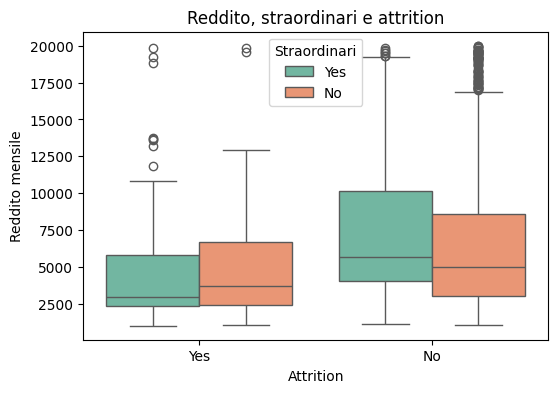

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x= "Attrition",
    y= "MonthlyIncome",
    hue= "OverTime",
    data= df,
    palette= "Set2"
)

plt.legend(title= "Straordinari")
plt.xlabel("Attrition")
plt.ylabel("Reddito mensile")


plt.title("Reddito, straordinari e attrition")
plt.show()


**Considerazioni**: i dipendenti che hanno lasciato l’azienda (Attrition = Yes) tendono ad avere redditi più bassi rispetto a quelli che sono rimasti, indipendentemente dallo svolgimento di straordinari.
Inoltre, tra i dipendenti che effettuano straordinari, quelli che abbandonano presentano una mediana di reddito inferiore rispetto a quelli che rimangono.
Il reddito potrebbe essere un fattore rilevante nell’attrition, e che gli straordinari, se associati a livelli retributivi più bassi, potrebbero contribuire ad aumentare il rischio di abbandono.

### Domanda 2 - La soddisfazione lavorativa influisce sull’`attrition`?

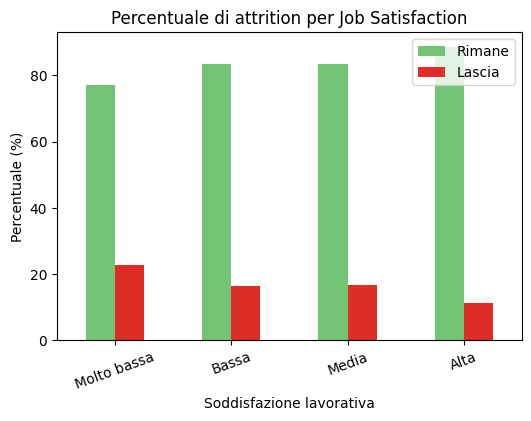

In [20]:
tab = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize= "index"
) * 100

tab.index = ["Molto bassa", "Bassa", "Media", "Alta"]
tab.plot(kind= "bar", figsize=(6,4), color=["#74c476", "#de2d26"])

plt.legend(["Rimane", "Lascia"])
plt.xlabel("Soddisfazione lavorativa")
plt.ylabel("Percentuale (%)")
plt.xticks(rotation=20)

plt.title("Percentuale di attrition per Job Satisfaction")
plt.show()


**Considerazioni**: all’aumentare della soddisfazione lavorativa la percentuale di attrition diminuisce in modo evidente. I dipendenti con bassa soddisfazione presentano una maggiore probabilità di abbandono, mentre quelli con livelli più alti tendono a rimanere.
**La soddisfazione lavorativa quindi è uno dei principali fattori associati all’attrition.**



### Domanda 3 - `work-life` balance influisce sull’`attrition`?





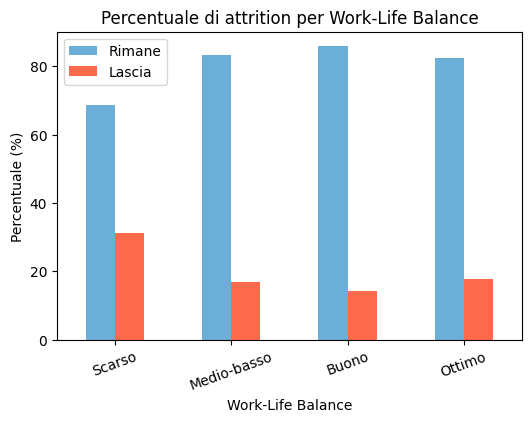

In [21]:
tab = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize= "index"
) * 100

tab.index = ["Scarso", "Medio-basso", "Buono", "Ottimo"]
tab.plot(kind= "bar", figsize=(6,4), color=["#6baed6", "#fb6a4a"])

plt.legend(["Rimane", "Lascia"])
plt.xlabel("Work-Life Balance")
plt.ylabel("Percentuale (%)")
plt.xticks(rotation= 20)

plt.title("Percentuale di attrition per Work-Life Balance")
plt.show()

**Considerazioni**: la percentuale di attrition è più alta nei dipendenti con un work-life balance scarso e diminuisce progressivamente al migliorare dell’equilibrio vita-lavoro. Tuttavia, il livello “ottimo” non mostra un ulteriore calo significativo rispetto a “buono”, suggerendo una possibile stabilizzazione dell’effetto.

# Domanda 4 - `JobSatisfaction` e `WorkLifeBalance` sono correlate?

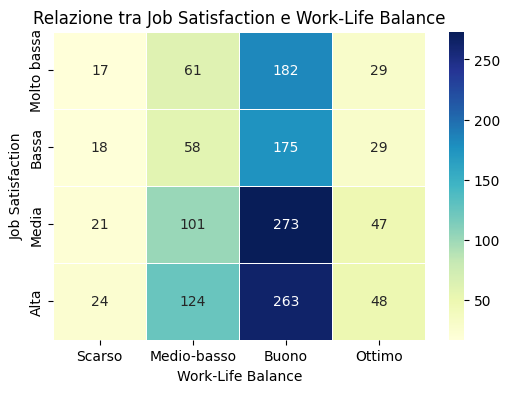

In [22]:
tab = pd.crosstab(
    df["JobSatisfaction"],
    df["WorkLifeBalance"]
)

tab.index = ["Molto bassa", "Bassa", "Media", "Alta"]
tab.columns = ["Scarso", "Medio-basso", "Buono", "Ottimo"]

plt.figure(figsize=(6,4))

sns.heatmap(
    tab,
    annot=True,
    cmap="YlGnBu",
    fmt="d",
    linewidths=0.5,
    linecolor="white"
)
plt.title("Relazione tra Job Satisfaction e Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Job Satisfaction")

plt.show()

In [23]:
tab= pd.crosstab(
    df["JobSatisfaction"],
    df["WorkLifeBalance"],
    normalize="index"
) * 100

tab.index= ["Molto bassa", "Bassa", "Media", "Alta"]
tab.columns= ["Scarso", "Medio-basso", "Buono", "Ottimo"]

print(tab.round(2))

             Scarso  Medio-basso  Buono  Ottimo
Molto bassa    5.88        21.11  62.98   10.03
Bassa          6.43        20.71  62.50   10.36
Media          4.75        22.85  61.76   10.63
Alta           5.23        27.02  57.30   10.46


**Considerazioni**: la distribuzione percentuale del work-life balance risulta molto simile per tutti i livelli di job satisfaction.
In particolare, la maggior parte dei dipendenti presenta un livello “buono”, indipendentemente dal grado di soddisfazione lavorativa, mentre le altre categorie rimangono relativamente stabili. Quindi vi è assenza di una relazione forte tra le due variabili. Questo indica che job satisfaction e work-life balance rappresentano dimensioni distinte.

##Domanda 5 - I dipendenti più “a rischio” di attrition si concentrano in specifiche combinazioni di età e esperienza?



In [24]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 60],
    labels=[
        "Giovani (18-25)",
        "Giovani adulti (26-35)",
        "Adulti (36-45)",
        "Senior (46-60)"
    ]
)

In [25]:
df["Experience"] = pd.cut(
    df["YearsAtCompany"],
    bins=[0, 3, 10, 40],
    labels=["Nuovi", "Intermedi", "Esperti"]
)

In [26]:
tab = pd.crosstab(
    [df["AgeGroup"], df["Experience"]],
    df["Attrition"],
    normalize="index"
) * 100

tab.round(2)

Attrition                             No    Yes
AgeGroup               Experience              
Giovani (18-25)        Nuovi       58.33  41.67
                       Intermedi   85.71  14.29
Giovani adulti (26-35) Nuovi       69.59  30.41
                       Intermedi   85.20  14.80
                       Esperti     90.62   9.38
Adulti (36-45)         Nuovi       84.87  15.13
                       Intermedi   92.89   7.11
                       Esperti     92.98   7.02
Senior (46-60)         Nuovi       90.62   9.38
                       Intermedi   84.56  15.44
                       Esperti     91.18   8.82

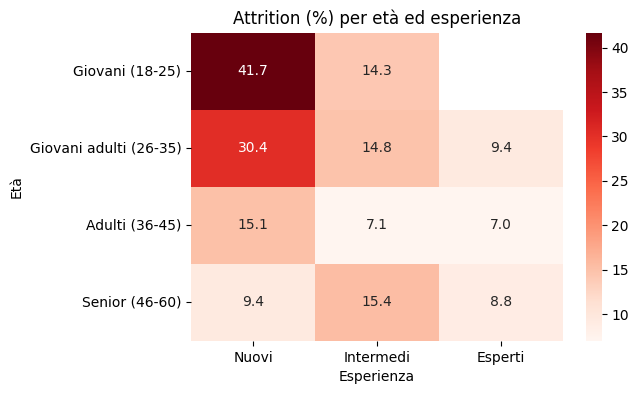

In [27]:
tab_reset = tab.reset_index()
pivot = tab_reset.pivot(
    index= "AgeGroup",
    columns= "Experience",
    values= "Yes"
)

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="Reds", fmt=".1f")

plt.xlabel("Esperienza")
plt.ylabel("Età")

plt.title("Attrition (%) per età ed esperienza")
plt.show()

**Considerazioni**: l’analisi congiunta di età ed esperienza mostra che l’attrition è più elevata tra i dipendenti più giovani e con minore esperienza. Nella fascia 18–25 anni si osserva il valore più alto (41.7%) tra i lavoratori “nuovi”. All’aumentare dell’esperienza, la probabilità di attrition diminuisce in tutte le fasce d’età, indicando una maggiore stabilità dei dipendenti con più anni in azienda.
Inoltre, per le fasce più adulte (36–45 e 46–60), i livelli di attrition sono più bassi e meno variabili tra i gruppi.
**Questo evidenzia che il rischio di abbandono si concentra principalmente nelle fasi iniziali della carriera**

##Domanda 6 - Chi ha cambiato più aziende ha più probabilità di lasciare?

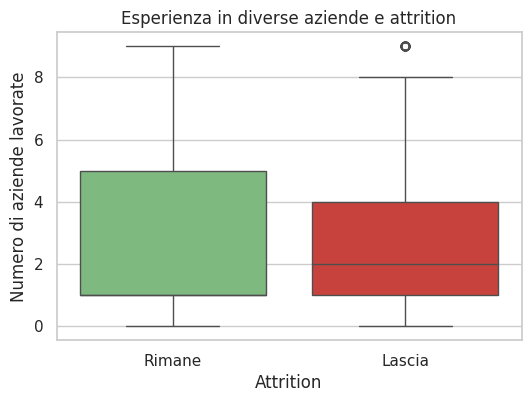

In [59]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Attrition",
    y="NumCompaniesWorked",
    hue= "Attrition",
    data=df,
    palette=["#74c476", "#de2d26"]
)

# Cambiamo le etichette per chiarezza
plt.xticks(ticks=[0,1], labels=["Rimane", "Lascia"])

plt.xlabel("Attrition")
plt.ylabel("Numero di aziende lavorate")

plt.title("Esperienza in diverse aziende e attrition")
plt.show()

**Considerazioni**: la sovrapposizione delle distribuzioni indica che la mobilità lavorativa passata non è lagato all’attrition.

# Conclusioni fase 3:


* l’attrition è influenzato dalla combinazione di variabili individuali e condizioni lavorative;
* la soddisfazione lavorativa risulta essere uno dei fattori più rilevanti: livelli più bassi sono associati a una maggiore probabilità di abbandono;
* il work-life balance influisce sull’attrition: un equilibrio vita-lavoro più scarso è collegato a percentuali più alte di uscita dall’azienda, ma l’effetto tende a stabilizzarsi ai livelli più elevati,
* l'analisi per età ed esperienza mostra che il rischio di attrition è più alto tra i dipendenti giovani e con minore anzianità, mentre diminuisce con l’aumentare dell’esperienza lavorativa
* il reddito ha un ruolo nel distinguere i dipendenti che lasciano da quelli che rimangono
* alcune variabili, come il numero di aziende precedentemente lavorate, non mostrano invece una relazione significativa.


Nel complesso, i risultati indicano che l’attrition dipende da una combinazione di fattori, tra cui soddisfazione, benessere lavorativo e fase della carriera, piuttosto che da una singola variabile.





---


# Fase 4

**Obiettivo:** confrontare almeno 3 modelli diversi per predire `Attrition`,
includendo almeno un modello lineare (regressione logistica) e almeno un
modello non lineare (k-NN e/o Random Forest).

## 4.1 Preparazione del dataset

Prima di addestrare i modelli dobbiamo:

1. rimuovere le colonne non informative individuate in Fase 2;
2. convertire le variabili categoriche in numeriche (con `pd.get_dummies`);
3. separare le feature (`X`) dal target (`y`);
4. effettuare il train/test split.


1. Togliamo le colonne non informative

In [29]:
cols_drop = constant_cols + ["EmployeeNumber", "Attrition", "Attrition_num"]

X_raw = df.drop(columns=cols_drop)
y = df["Attrition_num"]

print("Colonne rimosse:", cols_drop)
print("Numero di feature prima della codifica:", X_raw.shape[1])

Colonne rimosse: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber', 'Attrition', 'Attrition_num']
Numero di feature prima della codifica: 32


2. conversione delle variabili categoriche in numeriche

In [30]:
X = pd.get_dummies(X_raw, drop_first=True)

print("Numero di feature dopo la codifica:", X.shape[1])
X.head()

Numero di feature dopo la codifica: 49


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,AgeGroup_Giovani adulti (26-35),AgeGroup_Adulti (36-45),AgeGroup_Senior (46-60),Experience_Intermedi,Experience_Esperti
0,41,1102,1,2,2,94,3,2,4,5993,...,True,False,False,True,True,False,True,False,True,False
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,True,False,False,False,False,True,True,False
2,37,1373,2,2,4,92,2,1,3,2090,...,False,False,False,True,True,False,True,False,False,False
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,True,False,True,True,False,False,True,False
4,27,591,2,1,1,40,3,1,2,3468,...,False,False,True,False,False,True,False,False,False,False


3. Creo Train e Test

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print()
print("Proporzione Attrition=Yes nel training set:", y_train.mean().round(3))
print("Proporzione Attrition=Yes nel test set:", y_test.mean().round(3))

Training set: (1029, 49)
Test set: (441, 49)

Proporzione Attrition=Yes nel training set: 0.161
Proporzione Attrition=Yes nel test set: 0.161


# 4.2 Standardizzazione

La standardizzazione è importante per il k-NN (che si basa sulla distanza tra punti) e utile anche per la regressione logistica (per confrontare i coefficienti). Per la Random Forest non è necessaria, ma non è dannosa: per semplicità usiamo le stesse versioni standardizzate per tutti i modelli.

Calcoliamo media e deviazione standard solo sul training set, e applichiamo la stessa trasformazione al test set, per evitare data leakage.

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,AgeGroup_Giovani adulti (26-35),AgeGroup_Adulti (36-45),AgeGroup_Senior (46-60),Experience_Intermedi,Experience_Esperti
853,-1.958919,-0.413973,-0.036578,-0.866067,0.270496,-0.547908,0.37805,-0.998363,-1.538894,-0.867017,-1.009049,-0.689111,2.691496,2.339166,0.234944,-0.935308,-1.343310,1.015228,0.335827,-0.998443,-0.902661,-0.679685,-1.168838,-0.468182,0.636975,0.735132,-0.667252,1.206585,-0.356446,-0.673342,-0.223607,-0.338885,0.828785,-0.193128,-0.463547,-0.278365,-0.329903,-0.235339,2.068072,-0.550029,-0.230704,-0.929586,1.475102,-0.644520,-0.848962,-0.677919,-0.480480,-1.030594,-0.447996
435,-0.430695,1.176070,0.699024,-1.835797,-0.651162,-0.449557,0.37805,0.846010,0.264662,1.532088,1.404772,1.714602,-0.877511,-0.427503,1.154171,-0.935308,0.478372,-0.598161,1.734881,0.010293,0.493249,1.493316,0.812136,-0.468182,0.636975,0.735132,-0.667252,-0.828785,-0.356446,1.485129,-0.223607,-0.338885,0.828785,-0.193128,-0.463547,3.592409,-0.329903,-0.235339,-0.483542,-0.550029,-0.230704,1.075748,-0.677919,1.551543,1.177910,-0.677919,-0.480480,0.970314,-0.447996
587,1.643324,1.296833,0.208623,1.073395,1.192155,0.829007,0.37805,-0.076177,0.264662,-0.737494,1.017664,2.115221,1.318801,2.339166,-0.684284,0.247041,-0.302349,0.208533,0.335827,-0.325952,-0.623479,-0.369256,-0.036853,-0.468182,0.636975,0.735132,-0.667252,1.206585,-0.356446,-0.673342,-0.223607,-0.338885,-1.206585,-0.193128,2.157277,-0.278365,-0.329903,-0.235339,-0.483542,-0.550029,-0.230704,1.075748,-0.677919,-0.644520,-0.848962,-0.677919,2.081251,0.970314,-0.447996
1170,-1.085648,-0.549831,-0.894779,0.103664,1.192155,1.074884,0.37805,-0.998363,1.166440,-0.860942,-1.130107,-0.288492,-0.602972,-0.427503,0.234944,-0.935308,-0.692709,-2.211550,-1.063226,-0.494075,-0.623479,-0.369256,-0.602845,2.135922,-1.569919,0.735132,-0.667252,-0.828785,-0.356446,1.485129,-0.223607,-0.338885,0.828785,-0.193128,-0.463547,-0.278365,-0.329903,-0.235339,2.068072,-0.550029,-0.230704,-0.929586,1.475102,-0.644520,1.177910,-0.677919,-0.480480,0.970314,-0.447996
159,-0.321536,-1.274408,-0.894779,1.073395,0.270496,0.484778,0.37805,-0.998363,0.264662,-0.936660,-0.435997,1.313983,0.769723,-0.427503,1.154171,0.247041,-0.692709,0.208533,0.335827,-0.494075,-0.344297,-0.369256,-0.602845,2.135922,-1.569919,-1.360300,1.498685,-0.828785,2.805475,-0.673342,-0.223607,-0.338885,-1.206585,-0.193128,-0.463547,-0.278365,-0.329903,-0.235339,-0.483542,-0.550029,4.334566,1.075748,-0.677919,-0.644520,1.177910,-0.677919,-0.480480,0.970314,-0.447996


##4.3 Modello 1 - Regressione logistica (modello lineare)

In [43]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

pred_log = log_model.predict(X_test_scaled)
acc_log = accuracy_score(y_test, pred_log)

print(f"Accuracy regressione logistica: {acc_log:.3f}")

Accuracy regressione logistica: 0.875


--> lo scaling serve davvero?”

In [44]:
# Logistic senza scaling
log_model_raw = LogisticRegression(max_iter=1000, random_state=42)
log_model_raw.fit(X_train, y_train)

pred_raw = log_model_raw.predict(X_test)
acc_raw = accuracy_score(y_test, pred_raw)

print(f"Accuracy senza scaling: {acc_raw:.3f}")
print(f"Accuracy con scaling: {acc_log:.3f}")


Accuracy senza scaling: 0.850
Accuracy con scaling: 0.875


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Considerazioni**: il confronto tra il modello con e senza standardizzazione mostra che lo scaling migliora le prestazioni della regressione logistica (accuracy da 0.850 a 0.875).
Inoltre, il modello senza scaling presenta un warning di mancata convergenza, segno di difficoltà nel processo di ottimizzazione.
Questo evidenzia che la standardizzazione delle feature è importante per la regressione logistica, poiché permette una migliore convergenza e risultati più stabili.

##4.4 Modello 2 - k-Nearest Neighbors (modello non lineare)

Individuiamo il valore k con l'accuracy più alta e utilizzamolo per il modello.

In [45]:
k_values = [1, 3, 5, 7, 9, 11, 14, 18, 21, 35, 51]

results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    results.append({"k": k, "accuracy": acc})

knn_results = pd.DataFrame(results)
knn_results

,k,accuracy
0,1,0.793651
1,3,0.836735
2,5,0.845805
3,7,0.845805
4,9,0.841270
5,11,0.841270
6,14,0.839002
7,18,0.841270
8,21,0.839002
9,35,0.845805


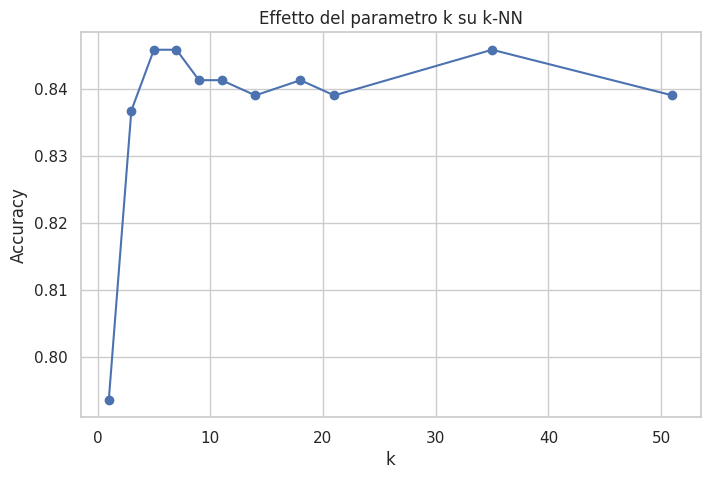

In [46]:
#grafico sui valori k e l'accuracy correlata
plt.figure(figsize=(8,5))
plt.plot(knn_results["k"], knn_results["accuracy"], marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Effetto del parametro k su k-NN")
plt.show()

Individuiamo il valore k = 14 come il valore con l'accuracy più alta e fissiamo il modello che analizzeremo in seguito.

In [47]:
knn_model = KNeighborsClassifier(n_neighbors=14)
knn_model.fit(X_train_scaled, y_train)

pred_knn = knn_model.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, pred_knn)

print(f"Accuracy k-NN (k=14): {acc_knn:.3f}")

Accuracy k-NN (k=14): 0.839


##4.5 Modello 3 - Random Forest (modello non lineare)


In [48]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)

pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, pred_rf)

print(f"Accuracy Random Forest: {acc_rf:.3f}")

Accuracy Random Forest: 0.832


4.5.1. Decision tree

In [51]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

pred_dt = dt_model.predict(X_test_scaled)
acc_dt = accuracy_score(y_test, pred_dt)

print(f"Accuracy Decision Tree: {acc_dt:.3f}")

Accuracy Decision Tree: 0.744


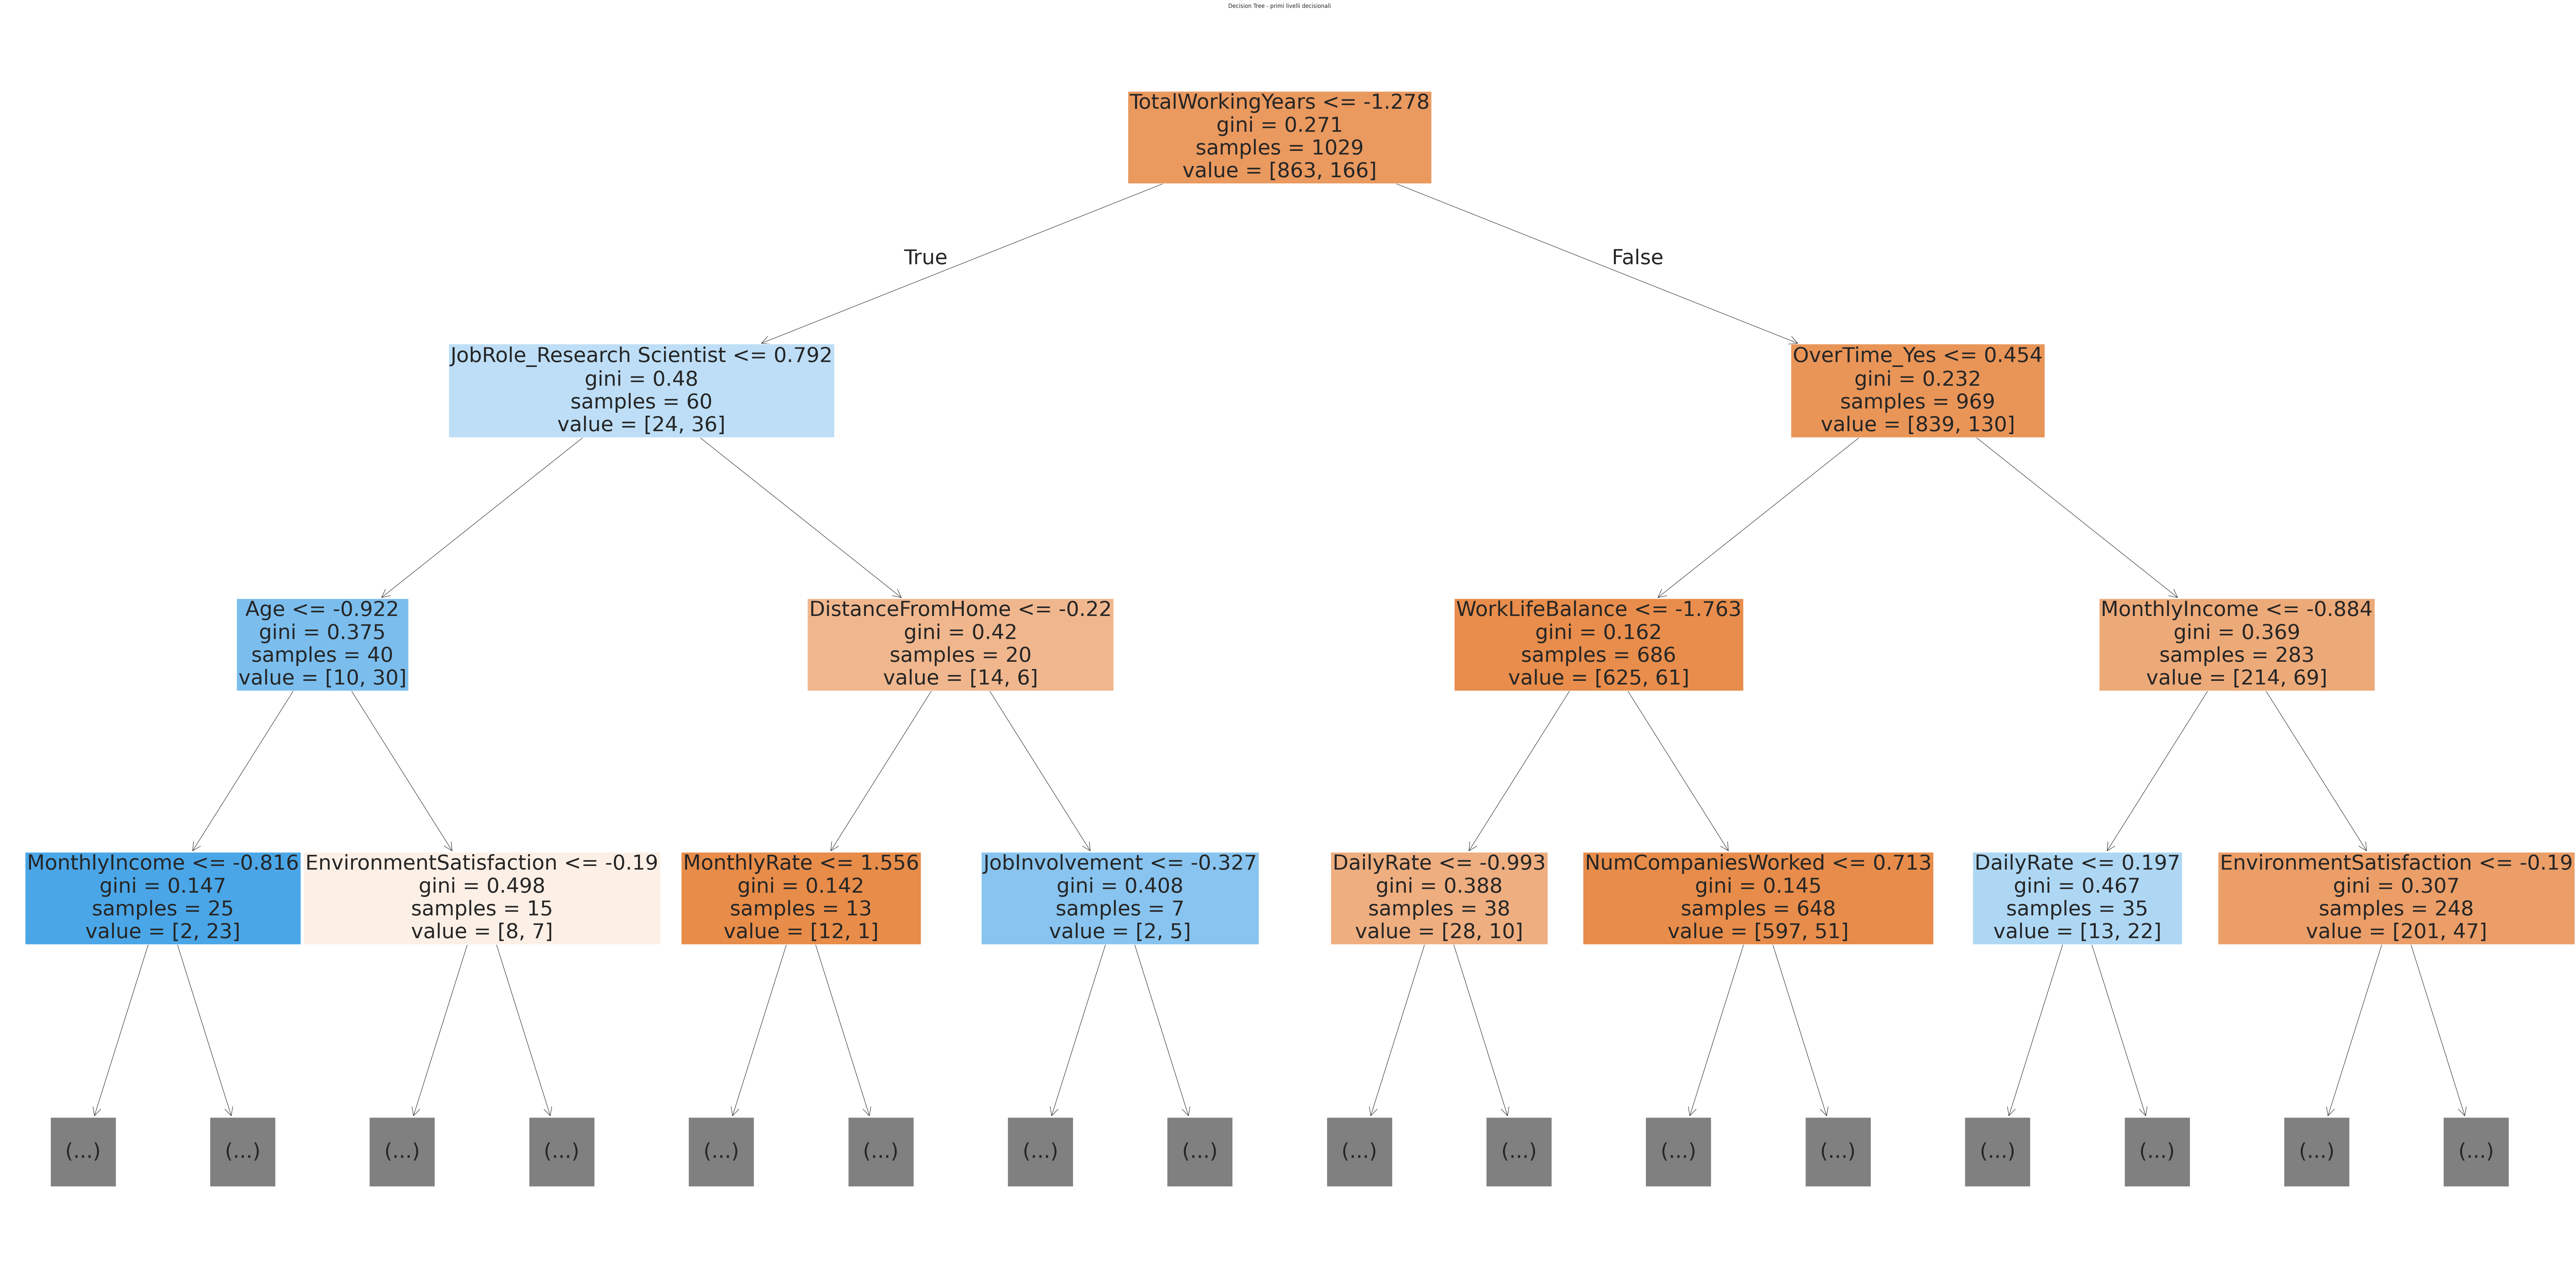

In [66]:
plt.figure(figsize=(100,50))
plot_tree(dt_model,
          filled=True,
          max_depth=3,
          feature_names=X.columns,
          fontsize=45
)
plt.title("Decision Tree - primi livelli decisionali")
plt.show()

**Considerazioni**: il Decision Tree mostra prestazioni inferiori rispetto agli altri modelli (accuracy 0.74) e fatica a individuare correttamente i casi di attrition, con valori bassi di precision e recall per la classe 1 (Attrition = Yes).
Confrontando i due modelli, la Random Forest risulta più accurata e stabile. Tuttavia, entrambi mostrano difficoltà nel riconoscere i casi di attrition, evidenziando un limite legato allo sbilanciamento dei dati. Il Decision Tree offre una maggiore interpretabilità, mentre la Random Forest garantisce migliori prestazioni.


# Conclusioni Fase 4
* Il dataset è stato correttamente preparato:
1. rimuovendo le variabili non informative,
2. trasformando quelle categoriche
3. suddividendo i dati in training e test set.

* La standardizzazione delle feature ha migliorato le prestazioni della regressione logistica e del k-NN.

* La regressione logistica risulta il modello più efficace, con la migliore accuracy e un buon equilibrio generale nelle prestazioni.

* Il k-NN mostra buoni risultati, ma è sensibile alla scelta del parametro k.

* La Random Forest offre prestazioni solide e una maggiore capacità di catturare relazioni complesse tra le variabili.

* Il Decision Tree è il modello meno accurato, ma ha il vantaggio di essere facilmente interpretabile e di rendere visibili le regole decisionali.


Tutti i modelli mostrano una difficoltà nel riconoscere correttamente i casi di attrition, suggerendo che la classe “Attrition = Yes” è più complessa da prevedere rispetto a quella dei dipendenti che rimangono.

---
# Fase 5 - Valutazione e interpretazione dei risultati

**Obiettivo**: valutazione critica dei risultati. Per ogni modello calcoliamo accuracy, confusion matrix, precision, recall e f1-score.



## 5.1 Regressione logistica

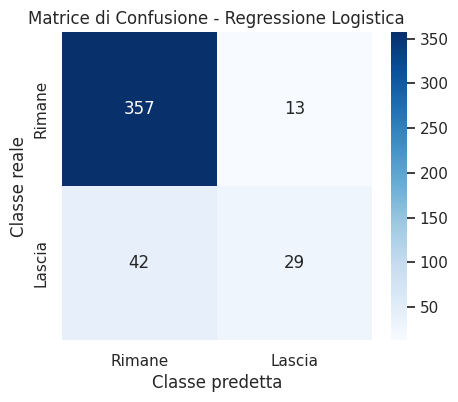

              precision    recall  f1-score   support

      Rimane       0.89      0.96      0.93       370
      Lascia       0.69      0.41      0.51        71

    accuracy                           0.88       441
   macro avg       0.79      0.69      0.72       441
weighted avg       0.86      0.88      0.86       441



In [78]:
cm_log = confusion_matrix(y_test, pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Classe predetta")
plt.ylabel("Classe reale")

plt.xticks(ticks=[0.5, 1.5], labels=["Rimane", "Lascia"])
plt.yticks(ticks=[0.5, 1.5], labels=["Rimane", "Lascia"])

plt.title("Matrice di Confusione - Regressione Logistica")
plt.show()

print(classification_report(y_test, pred_log, target_names=["Rimane", "Lascia"]))



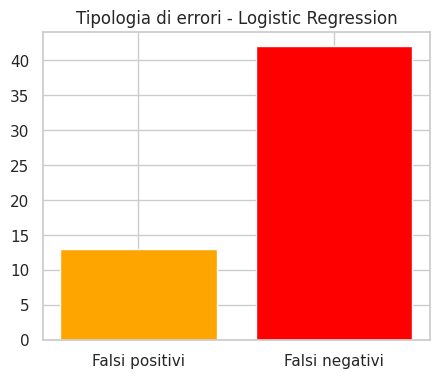

In [99]:
cm = confusion_matrix(y_test, pred_log)

fp = cm[0,1]
fn = cm[1,0]

labels = ["Falsi positivi", "Falsi negativi"]
values = [fp, fn]

plt.figure(figsize=(5,4))
plt.bar(labels, values, color=["orange", "red"])

plt.title("Tipologia di errori - Logistic Regression")
plt.show()


I falsi negativi risultano particolarmente rilevanti, poiché rappresentano dipendenti che lasciano l’azienda ma non vengono identificati dal modello, riducendone l’utilità pratica.

##5.2 k-NN

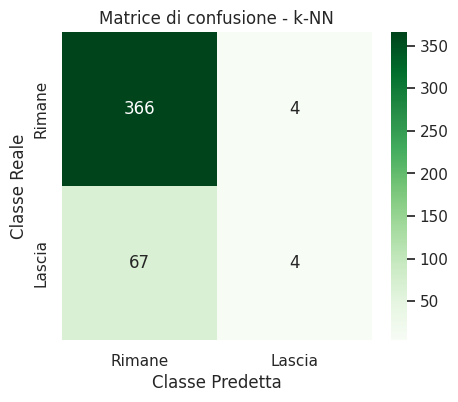

              precision    recall  f1-score   support

      Rimane       0.85      0.99      0.91       370
      Lascia       0.50      0.06      0.10        71

    accuracy                           0.84       441
   macro avg       0.67      0.52      0.51       441
weighted avg       0.79      0.84      0.78       441



In [84]:
cm_knn = confusion_matrix(y_test, pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")

plt.xticks(ticks=[0.5, 1.5], labels=["Rimane", "Lascia"])
plt.yticks(ticks=[0.5, 1.5], labels=["Rimane", "Lascia"])

plt.title("Matrice di confusione - k-NN")
plt.show()
print(classification_report(y_test, pred_knn, target_names=["Rimane", "Lascia"]))

##5.3 Random Forest

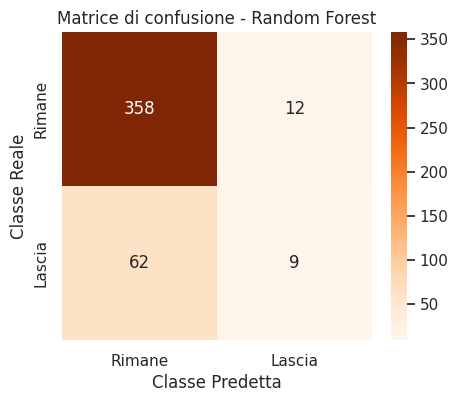

              precision    recall  f1-score   support

      Rimane       0.85      0.97      0.91       370
      Lascia       0.43      0.13      0.20        71

    accuracy                           0.83       441
   macro avg       0.64      0.55      0.55       441
weighted avg       0.78      0.83      0.79       441



In [86]:
cm_rf = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges")

plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")

plt.xticks(ticks=[0.5, 1.5], labels=["Rimane", "Lascia"])
plt.yticks(ticks=[0.5, 1.5], labels=["Rimane", "Lascia"])

plt.title("Matrice di confusione - Random Forest")
plt.show()
print(classification_report(y_test, pred_rf, target_names=["Rimane", "Lascia"]))

#5.3.1 Decision Tree

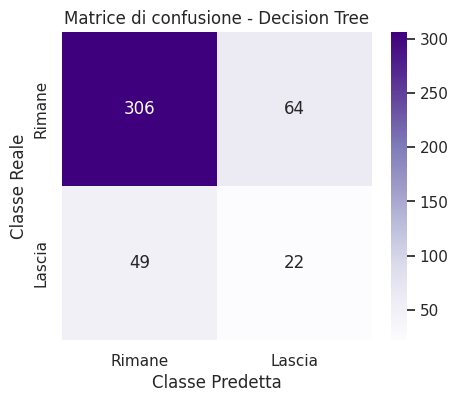

              precision    recall  f1-score   support

      Rimane       0.86      0.83      0.84       370
      Lascia       0.26      0.31      0.28        71

    accuracy                           0.74       441
   macro avg       0.56      0.57      0.56       441
weighted avg       0.76      0.74      0.75       441



In [88]:
cm_dt = confusion_matrix(y_test, pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Purples")

plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")

plt.xticks(ticks=[0.5, 1.5], labels=["Rimane", "Lascia"])
plt.yticks(ticks=[0.5, 1.5], labels=["Rimane", "Lascia"])

plt.title("Matrice di confusione - Decision Tree")
plt.show()
print(classification_report(y_test, pred_dt, target_names=["Rimane", "Lascia"]))

# **Considerazioni**:
le metriche e le confusion matrix mostrano che tutti i modelli ottengono buone prestazioni generali nel classificare i dipendenti che rimangono. Emerge una difficoltà comune nell’individuare correttamente i casi di attrition (classe “Lascia”), come evidenziato dai valori più bassi di recall e dalla presenza di falsi negativi.

La regressione logistica risulta il modello più equilibrato, mentre k-NN e Random Forest mostrano buone performance ma con una minore capacità di riconoscere la classe minoritaria. Il Decision Tree è il modello meno accurato, ma il più interpretabile.







## 5.2. Analisi delle variabili più rilevanti


In [89]:
coeff = pd.Series(log_model.coef_[0], index=X.columns)
coeff_sorted = coeff.sort_values(key=abs, ascending=False)
coeff_sorted.head(10)

,0
OverTime_Yes,0.898678
JobRole_Sales Executive,0.760471
BusinessTravel_Travel_Frequently,0.695594
JobRole_Laboratory Technician,0.682501
JobRole_Sales Representative,0.605270
YearsSinceLastPromotion,0.537301
Age,-0.496218
TotalWorkingYears,-0.487514
NumCompaniesWorked,0.484932
EnvironmentSatisfaction,-0.462373


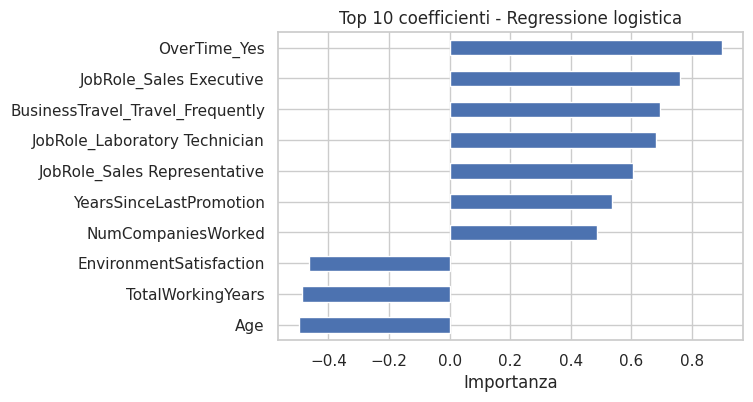

In [90]:
top_coeff = coeff_sorted.head(10)

plt.figure(figsize=(6,4))
top_coeff.sort_values().plot(kind="barh")

plt.xlabel("Importanza")
plt.title("Top 10 coefficienti - Regressione logistica")
plt.show()

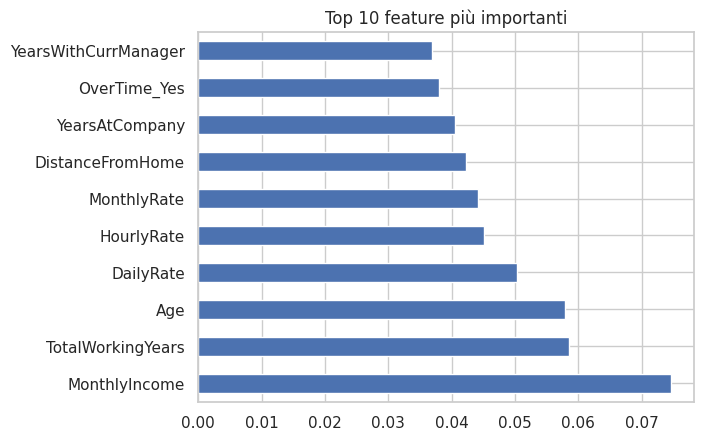

In [91]:
importances = rf_model.feature_importances_
feat_importance = pd.Series(importances, index=X.columns)

top_features = feat_importance.sort_values(ascending=False).head(10)

top_features.plot(kind="barh")
plt.title("Top 10 feature più importanti")
plt.show()

**Considerazioni**: i risultati mostrano che le variabili più influenti per la previsione dell’attrition sono legate principalmente a reddito, esperienza lavorativa, età e condizioni lavorative, come la presenza di straordinari.
Questi fattori risultano coerenti con quanto emerso nell’analisi esplorativa (fase 3), confermando che le variabili individuate in precedenza hanno un ruolo rilevante anche nei modelli predittivi.

##5.3. Confronto tra modelli


In [95]:
#tabella di confronto
comparison = pd.DataFrame({
    "Modello": ["Logistic Regression", "k-NN", "Random Forest", "Decision Tree"],

    "Accuracy": [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_dt)
    ],

    "Recall (Lascia)": [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_dt)
    ],

    "Precision (Lascia)": [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_knn),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_dt)
    ],

    "F1-score (Lascia)": [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_dt)
    ]
})

comparison = comparison.round(3)
comparison

,Modello,Accuracy,Recall (Lascia),Precision (Lascia),F1-score (Lascia)
0,Logistic Regression,0.875,0.408,0.690,0.513
1,k-NN,0.839,0.056,0.500,0.101
2,Random Forest,0.832,0.127,0.429,0.196
3,Decision Tree,0.744,0.310,0.256,0.280


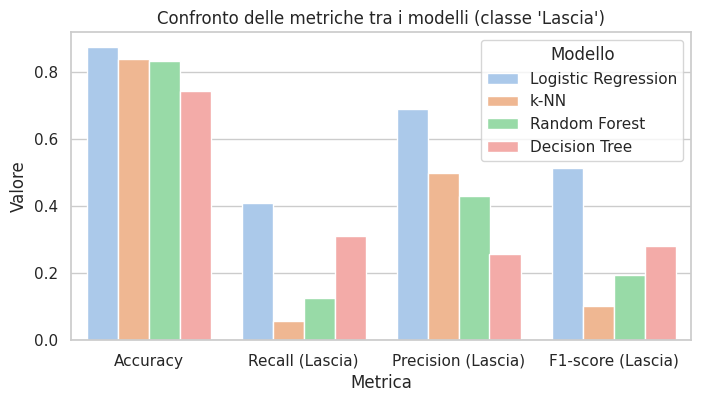

In [100]:
comparison_melted = comparison.melt(
    id_vars="Modello",
    var_name="Metrica",
    value_name="Valore"
)

comparison_melted = comparison_melted[
    comparison_melted["Metrica"] != "Modello"
]

plt.figure(figsize=(8,4))

sns.barplot(
    data=comparison_melted,
    x="Metrica",
    y="Valore",
    hue="Modello",
    palette="pastel"
)

plt.title("Confronto delle metriche tra i modelli (classe 'Lascia')")
plt.ylabel("Valore")
plt.xlabel("Metrica")

plt.title("Confronto delle metriche tra i modelli (classe 'Lascia')")
plt.show()

**Considerazioni**: il confronto tra i modelli mostra che la regressione logistica ottiene le migliori prestazioni complessive, in particolare per quanto riguarda il recall della classe “Lascia”, risultando più efficace nell’individuare i dipendenti a rischio di abbandono.

---
# Conclusioni e possibili approfondimenti